<center>
<img src="https://raw.githubusercontent.com/FUlyankin/r_probability/master/end_seminars_2020/sem08/real_expect.png" width="500">

# Домашнее задание 5: параметрические тесты
</center>

**ФИО:** Даньшина Василиса Ивановна

## Общая информация

__Дедлайн:__ 23:59MSK 31.05.2025

In [1]:
import numpy as np
import pandas as pd

import scipy.stats as sts
import matplotlib.pyplot as plt
import seaborn as sns

### Задача №1: Лучше найди себе девушку! (25 баллов)

В этой задаче вам предстоит проверить несколько гипотез на датасете из американского сервиса знакомств. Датасет называется `dating_is_hard.csv`

Колонки датасета:
- `age` - возраст
- `is_heavy_drinker` - алкоголизм в булевом виде
- `height` - рост в дюймах
- `sex` - полов может быть только два - f для женщин и m для мужчин.
- `smokes` - зависимость от табака в булевом виде
- `location` - место жительства
- `offspring` - отношение к детям

Для каждого пункта нужно расписать нулевую и альтернативную гипотезу, описать какой именно критерий вы используете, перечислить предпослыки необходимые для его использования, а также вычислить значение статистики и p-value, если это возможно.

In [5]:
df = pd.read_csv('dating_is_hard.csv')
df

,Unnamed: 0,age,is_heavy_drinker,height,sex,smokes,location,offspring
0,uid_1,27,False,64,f,True,san francisco california,no opinion
1,uid_2,38,False,65,f,False,oakland california,wants kids
2,uid_3,31,False,70,m,True,san francisco california,does not have kids
3,uid_4,29,False,66,m,False,martinez california,does not have kids
4,uid_5,30,False,69,m,True,san francisco california,no opinion
...,...,...,...,...,...,...,...,...
995,uid_996,18,False,67,m,True,vallejo california,no opinion
996,uid_997,21,False,70,m,False,san francisco california,does not have kids
997,uid_998,30,False,73,m,False,oakland california,does not have kids
998,uid_999,49,False,71,m,False,san francisco california,no opinion


__a) [5 баллов]__ Рост в приложениях для знакомств не проверяют, поэтому можно поставить себе любой и никто не узнает. Посмотрим же, врут ли люди о своём росте.

Проверьте две гипотезы: совпадает ли средний рост мужчин в приложении с их реальным средним ростом и совпадает ли средний рост женщин в приложении с их реальным средним ростом

__P.S.__ Средний рост мы вам не дамим. Ищите сами и приложите ссылку на источник в решении.

In [6]:
# ссылка на источник среднего роста в США - https://www.cdc.gov/nchs/fastats/body-measurements.htm

mu_male_real = 68.9
mu_female_real = 63.5

male_heights = df[df['sex'] == 'm']['height'].dropna()
female_heights = df[df['sex'] == 'f']['height'].dropna()

t_stat_m, p_val_m = sts.ttest_1samp(male_heights, mu_male_real)
print(f"Мужчины: t-statistic = {t_stat_m:.4f}, p-value = {p_val_m:.4e}")

t_stat_f, p_val_f = sts.ttest_1samp(female_heights, mu_female_real)
print(f"Женщины: t-statistic = {t_stat_f:.4f}, p-value = {p_val_f:.4e}")

Мужчины: t-statistic = 11.9399, p-value = 1.2549e-29
Женщины: t-statistic = 9.8483, p-value = 1.2552e-20


__Вывод:__
И мужчины, и женщины врут о своем росте. Так как в обоих случаях значение p-value очень низкие, мы отвергаем нулевую гипотезу (о том, что средний заявленнный рост пользователей совпадает с реальным средним ростом населения.

Положительный знак t-статистики у мужчин ($+11.9399$) говорит о том, что мужчины в приложении склонны завышать свой рост.

Знак t-статистики у женщин ($+9.8483$) также указывает на то, что средний рост женщин в анкетах значимо выше реального среднего по популяции.

__б) [10 баллов]__ По моим наблюдениям (состоящим из одного человека) мужчин-алкоголиков гораздо больше женщин. В нашем датасете алкоголизмом мы будем считать параметр `is_heavy_drinker`

Проверьте гипотезу: Действительно ли доля мужчин-алкоголиков выше доли женщин-алкоголиков?

In [7]:
from statsmodels.stats.proportion import proportions_ztest

heavy_m = df[df['sex'] == 'm']['is_heavy_drinker'].sum()
n_m = df[df['sex'] == 'm']['is_heavy_drinker'].count()

heavy_f = df[df['sex'] == 'f']['is_heavy_drinker'].sum()
n_f = df[df['sex'] == 'f']['is_heavy_drinker'].count()

z_stat, p_val = proportions_ztest([heavy_m, heavy_f], [n_m, n_f], alternative='larger')
print(f"Z-statistic = {z_stat:.4f}, p-value = {p_val:.4f}")

Z-statistic = 0.4235, p-value = 0.3360


__Вывод:__
Z-статистика (0.4235) показывает, что разница между долями мужчин и женщин составляет менее половины стандартного отклонения.
p-value = 0.3360, что значительно превышает выбранный уровень значимости alpha = 0.05. Значит у нас нет оснований отвергнуть нулевую гипотезу.

Наблюдение не подтвердилось на данном датасете.

__в) [10 баллов]__ Мой друг Володька решил бросить курить и теперь курит только когда пьёт. Это навело меня на мысль о том, что курение привлекает алкоголиков сильнее, чем обычных людей.

Проверьте гипотезу: Действительно ли алкоголики больше склонны к курению, чем неалкоголики?

In [8]:
smokers_drinker = df[df['is_heavy_drinker'] == True]['smokes'].sum()
n_drinker = df[df['is_heavy_drinker'] == True]['smokes'].count()

smokers_sober = df[df['is_heavy_drinker'] == False]['smokes'].sum()
n_sober = df[df['is_heavy_drinker'] == False]['smokes'].count()

z_stat_smoke, p_val_smoke = proportions_ztest([smokers_drinker, smokers_sober], [n_drinker, n_sober], alternative='larger')
print(f"Z-statistic = {z_stat_smoke:.4f}, p-value = {p_val_smoke:.4f}")

Z-statistic = 0.6743, p-value = 0.2501


**Вывод:**
Так как полученное значение p-value = 0.2501 существенно больше стандартного уровня значимости alpha = 0.05, мы снова не можем отвергнуть нулевую гипотезу. Статистический тест показывает, что разница в долях курящих среди алкоголиков и неалкоголиков в данном датасете не является значимой. Наблюдаемый в выборке перекос вполне мог возникнуть из-за обычного случайного шума.

### Задача №2. Тестируем новый интерфейс страницы отеля  (25 баллов)

Все мы любим отдыхать! А злые корпорации любят наживаться на нашем желании отдыхать.

Представим что вы работаете в одной из таких корпораций и занимаетесь аналитикой сайта для бронирования отелей. Процесс бронирования имеет привычную структуру:
- вбиваете в поиск направленния и даты
- получаете выдачу вариантов отелей
- переходите на страницу отеля
- нажимаете кнопку "забронировать"
- попадаете на страницу оплаты
- оплачиваете

Очевидно, на всех этапах этой воронки вы можете потерять пользователя. Поисследовав поведение пользователей вы решили внести изменения на странице об отеле и хотите чтобы выросла конверсия в бронирования

__а) [3 балла]__ Подумайте, какие изменения могли бы быть внесены?

**Ваш ответ:**

Перед вами датасет `ab_test.csv`, в нем содержатся данные о пользователях в период теста

`user_id` - уникальный идентификатор пользователя \
`sex` - пол пользователя \
`datetime` - дата и время посещения сайта (начала сессии) \
`district` - регион расположения отеля \
`hotel_page` - был ли пользователь на странице отеля в сессии \
`payment_page` - был ли пользователь на странице оплаты в сессии \
`payment` - была ли произведена оплата в сессии \
`group` - группа в эксперименте

Поскольку изменения вносились на странице отеля нас интересуют именно дошедшие до этой страницы пользователи. Поэтому колонка `hotel_page` принимает значение 1 всегда

In [4]:
df_ab = pd.read_csv("ab_simpson.csv")
df_ab.head()

,Unnamed: 0,user_id,sex,datetime,district,hotel_page,payment_page,payment,group
0,0,3326449108867616315,1,11/15/2023 12:02 AM,Южный федеральный округ,1,1,0,control
1,1,7887645543455909870,1,11/02/2023 09:12 PM,Центральный федеральный округ,1,1,0,control
2,2,6148146969124793824,1,11/10/2023 10:06 AM,Центральный федеральный округ,1,1,1,control
3,3,2721602951940155275,0,11/12/2023 07:10 PM,Центральный федеральный округ,1,1,0,control
4,4,1829030712785972138,0,05/01/2024 05:19 AM,Южный федеральный округ,1,0,0,test


__б) [3 балла]__ Сделайте небольшой eda, какие выводы вы можете сделать о данных? Корректно ли проводился аб тест? Найдите ошибки и объясните почему это некорректно.

In [5]:
print(df_ab.head())
print(df_ab.info())
print(df_ab['group'].value_counts())
print(df_ab['district'].value_counts())
print(df_ab['payment_page'].value_counts())
print(df_ab['payment'].value_counts())

# Проверка на дисбаланс по регионам между группами
cont_dist = df_ab[df_ab['group']=='control']['district'].value_counts(normalize=True)
test_dist = df_ab[df_ab['group']=='test']['district'].value_counts(normalize=True)
print(pd.concat([cont_dist, test_dist], axis=1, keys=['control', 'test']))

   Unnamed: 0              user_id  sex             datetime  \
0           0  3326449108867616315    1  11/15/2023 12:02 AM   
1           1  7887645543455909870    1  11/02/2023 09:12 PM   
2           2  6148146969124793824    1  11/10/2023 10:06 AM   
3           3  2721602951940155275    0  11/12/2023 07:10 PM   
4           4  1829030712785972138    0  05/01/2024 05:19 AM   

                        district  hotel_page  payment_page  payment    group  
0        Южный федеральный округ           1             1        0  control  
1  Центральный федеральный округ           1             1        0  control  
2  Центральный федеральный округ           1             1        1  control  
3  Центральный федеральный округ           1             1        0  control  
4        Южный федеральный округ           1             0        0     test  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 401807 entries, 0 to 401806
Data columns (total 9 columns):
 #   Column        Non-Null Cou

Вывод:
Видно, что распределение пользователей по округам сильно различается между группами.
Это нарушает рандомизацию. Группы формировались не случайно относительно региона. Такой A/B-тест некорректен.

Раскроем правду. Изменение продукта касалось адаптации страницы отеля под его регион. Например, в южных регионах пользователям на странице отеля предлагались активности для пляжного отдыха, а в северном и центральном регионе сразу подбирались ближайшие экскурсии и так далее.

__в) [5 баллов]__ Проанализируйте, как ведут себя конверсии в страницу оплаты и в оплату в разных регионах? Опишите выводы.

In [9]:
conv_page = df_ab.groupby(['district', 'group'])['payment_page'].mean().unstack()
print("Конверсия в payment_page по регионам:\n", conv_page)

df_paypage = df_ab[df_ab['payment_page'] == 1]
conv_pay = df_paypage.groupby(['district', 'group'])['payment'].mean().unstack()
print("\nКонверсия в payment (среди payment_page=1):\n", conv_pay)


Конверсия в payment_page по регионам:
 group                               control      test
district                                             
Дальневосточный федеральный округ  0.100050  0.200066
Приволжский федеральный округ      0.600000  0.649994
Северо-Западный федеральный округ  0.700005  0.720016
Сибирский федеральный округ        0.299975  0.320005
Уральский федеральный округ        0.399933  0.450007
Центральный федеральный округ      0.899999  0.930002
Южный федеральный округ            0.800000  0.810001

Конверсия в payment (среди payment_page=1):
 group                               control      test
district                                             
Дальневосточный федеральный округ  0.250000  0.363861
Приволжский федеральный округ      0.252449  0.337213
Северо-Западный федеральный округ  0.252877  0.333563
Сибирский федеральный округ        0.246455  0.328046
Уральский федеральный округ        0.251043  0.326070
Центральный федеральный округ      0.250452  0.3318

Вывод:
Новый интерфейс улучшает обе ключевые метрики во всех регионах
* Переход на страницу оплаты (payment_page) вырос.
* Фактическая оплата (payment) выросла

Таким образом, внутри каждого региона тест однозначно эффективнее контроля.

__г) [5 баллов]__ Проанализируйте, улучшилась ли воронка для пользователей в тестовой группе по сравнению с контрольной вне зависимости от региона? Опишите выводы.

In [11]:
from statsmodels.stats.proportion import proportions_ztest
overall_page = df_ab.groupby('group')['payment_page'].mean()
print("Общая конверсия в payment_page:\n", overall_page)

control_page = df_ab[df_ab['group']=='control']['payment_page'].sum()
control_n = len(df_ab[df_ab['group']=='control'])
test_page = df_ab[df_ab['group']=='test']['payment_page'].sum()
test_n = len(df_ab[df_ab['group']=='test'])
z_page, p_page = proportions_ztest([control_page, test_page], [control_n, test_n])
print(f"Z-тест для payment_page: z = {z_page:.4f}, p-value = {p_page:.4f}")

overall_pay = df_ab.groupby('group')['payment'].mean()
print("\nОбщая конверсия в payment:\n", overall_pay)
z_pay, p_pay = proportions_ztest([df_ab[df_ab['group']=='control']['payment'].sum(),
                                   df_ab[df_ab['group']=='test']['payment'].sum()],
                                  [control_n, test_n])
print(f"Z-тест для payment: z = {z_pay:.4f}, p-value = {p_pay:.4f}")

Общая конверсия в payment_page:
 group
control    0.756999
test       0.726803
Name: payment_page, dtype: float64
Z-тест для payment_page: z = 21.8685, p-value = 0.0000

Общая конверсия в payment:
 group
control    0.250170
test       0.333885
Name: payment, dtype: float64
Z-тест для payment: z = -58.3392, p-value = 0.0000


Вывод:
По переходу на страницу оплаты (payment_page) тестовая группа значимо хуже контрольной

По фактической оплате (payment) тестовая группа значимо лучше контрольной.

__д) [5 баллов]__ Проанализируйте распределение интересов пользователей в тестовой и контрольной группе. Какими регионами они интересовались? Изменились ли их предпочтения?

In [8]:
print(pd.crosstab(df_ab['district'], df_ab['group']))

group                              control   test
district                                         
Дальневосточный федеральный округ     1999   6058
Приволжский федеральный округ        23985  36348
Северо-Западный федеральный округ    39974  10097
Сибирский федеральный округ           7994   8078
Уральский федеральный округ           5996  20193
Центральный федеральный округ        79949  40387
Южный федеральный округ              39975  80774


Вывод: Последняя таблица обнажает главную проблему эксперимента — дисбаланс выборок. Трафик распределялся неравномерно:
Например, в Центральном ФО в контроль попало в 2 раза больше людей, чем в тест (79 949 против 40 387). В Южном ФО и Дальневосточном ФО ситуация обратная: в тесте пользователей оказалось в 2-3 раза больше, чем в контроле (например, на Юге: 80 774 в тесте против 39 975 в контроле).

Если вы все сделали правильно, то у вас получился противоречивые ответы в пунктах 3 и 4. Вы попали в ловушку Парадокса Симпсона. Подробнее о нем можно почитать [здесь](https://ru.wikipedia.org/wiki/Парадокс_Симпсона)

<img src="https://github.com/hse-econ-data-science/andan_2023/blob/main/hw/hw04/images/simpson.jpg?raw=true" width="350" align='center'>

__е) [4 балла]__ Теперь, когда вы все узнали, опишите кратко почему вы получили противоречивый результат в пунктах 3 и 4 (1 балл)

**Ваш ответ:**

Основная причина данного парадокса - сильный дисбаланс в распределении пользователей по регионам между группами.

В контрольной группе непропорционально много пользователей из регионов с очень высокой базовой конверсией в payment_page (Центральный, Северо-Западный).
В тестовой группе – непропорционально много пользователей из регионов с более низкой базовой конверсией (Южный, Уральский, Приволжский).

## Задача №3: Не подглядывать! (50 баллов)

<img src="https://github.com/hse-econ-data-science/andan_2023/blob/main/hw/hw04/images/trump.png?raw=true" width="500" align='left'>

На американских выборах 2020 года в некоторых штатах проходила очень конкурентная борьба между кандидатами. По мере подсчета голосов перевес в голосах склонялся то в пользу демократов, то в пользу республиканцев. И вот, в один из таких моментов, когда чаша весов склонилась в пользу республиканцев, Д. Трамп написал в твиттер "stop the count!", что означало призыв к остановке подсчета голосов.

_Здесь у вас мог возникнуть вопрос, и зачем нам это?_

Ответ очень прост. В этой ситуации всем очевидно, что призыв Трампа не мог быть осуществлен, то есть прерывать подсчет голосов раньше времени кажется довольно глупым способом выявления победителя. И вот абсолютно такой же способ принятия решения есть и в А/Б-тестах, только теперь многим аналитикам он уже кажется не столь очевидным, что приводит к существенным ошибкам в заключении выводов.

_Решив эту задачу, мы познакомимся с такой проблемой подробнее и поймем, как не стоит делать, когда вы запускаете А/Б-тест._

Чтобы понять, в чем же именно заключается проблема, мы с вами будем проводить симуляции А/Б-тестов. Это когда мы генерируем данные уже со знаниями, как эти данные устроены. А затем, запуская процедуру проверки гипотез над такими симулированными данными, мы будем оценивать, что происходит на практике (при запуске А/Б-теста).

На практике же всегда неизвестно, как устроены данные, и проводя А/Б-тест мы пытаемся зафиксировать различия. Еще раз, здесь же мы будем знать об устройстве данных, а затем будем смотреть на поведение А/Б-теста, то есть как будто бы смотреть на тест с обратной стороны.

_Перед тем как идти дальше, остановитесь здесь и еще раз зафиксируйте это!_

__а) [10 баллов]  Подсчет размера выборки для А/Б-теста__

Предположим, что вы хотите провести А/Б-тест внутри вашего приложения. Вы выбрали некоторую метрику $X$ – случайную величину из нормального распределения с мат. ожиданием $100$ у.е. и стандартным отклонением $40$ у.е – это ваш бейзлайн (группа А). Рассчитайте, сколько дней вам нужно крутить такой А/Б-тест, если:

1. Вы ожидаете получить минимальный размер эффекта в $5$ у.е.;
2. Вы хотите зафиксировать ошибку первого рода на уровне $\alpha=5\%$, а ошибку второго рода на уровне $\beta=20\%$;
3. Вы точно знаете, что в группе Б стандартное отклонение метрики составляет также $20$ у.е.
4. Посещаемость вашего приложения ежедневно составляет $200$ пользователей, и вы готовы раскатить тест на $100\%$ трафика.

Формула для расчета числа наблюдений _для одной группы_:

$$
n_{\text{one group}} = \frac{(\sigma_A^2 + \sigma_B^2) \cdot (z_{1-\frac{\alpha}{2}} + z_{1-\beta})^2}{MDE^2},
$$

__Подсказка:__ Помните, что после получения общего числа наблюдений вам нужно выразить это в дни! Вы должны получить целое число. Также будьте аккуратны с подсчетом трафика и кол-ва наблюдений – обратите внимание, со скольким числом групп вы работаете!

In [12]:
alpha = 0.05
beta= 0.20
sigma_A= 40
sigma_B = 20
mde = 5
daily_traffic_per_group = 100

z_alpha = sts.norm.ppf(1- alpha/2)
z_beta = sts.norm.ppf(1-beta)

n_one_group = ((sigma_A**2 + sigma_B**2)*(z_alpha + z_beta)**2) / (mde**2)
days = np.ceil(n_one_group / daily_traffic_per_group)

print(f"Необходимый размер группы: {int(np.ceil(n_one_group))}")
print(f"Количество дней для теста: {int(days)}")

Необходимый размер группы: 628
Количество дней для теста: 7


__б) [20 баллов] Симуляция А/Б-теста__

Теперь нам нужно запустить А/Б-тест. Для этого:

1. Сгенерируйте выборку данных из нормального распределения для группы А и Б в конкретный один день. Считайте, что в группе Б математическое ожидание составляет $105$ у.е., то есть с учетом размера вашего минимального ожидаемого эффекта из предыдущего пункта.

In [14]:
np.random.seed(42)
mu_A = 100
mu_B = 105

group_A = np.random.normal(mu_A, sigma_A, daily_traffic_per_group)
group_B = np.random.normal(mu_B, sigma_B, daily_traffic_per_group)

print("Первые 5 значений группы А:", group_A[:5])
print("Первые 5 значений группы Б:", group_B[:5])
print(f"Размер выборки А: {len(group_A)}, Б: {len(group_B)}")

Первые 5 значений группы А: [119.86856612  94.46942795 125.90754152 160.92119426  90.63386501]
Первые 5 значений группы Б: [ 76.69258516  96.58709354  98.14570967  88.95445462 101.77428577]
Размер выборки А: 100, Б: 100


2. Теперь представим, что наш тест был запущен $X$ дней. Напишите функцию, которая за этот период теста собирает в `DataFrame` следующие данные на каждый день теста:
    1. среднее метрики в группе А
    2. среднее метрики в группе Б
    3. p-value, посчитанное с помощью t-test – можно воспользоваться встроенной функцией `scipy.stats.ttest_ind`
    
    Соберите `DataFrame` для $X=50$.
    
__Подсказка:__ Среднее для 1-го дня должно считаться по пользователям, пришедших в первый день, для второго дня – по пользователям, пришедшим в первый и второй день и т.д. То есть накопленным итогом за каждый день теста.

In [16]:
def simulate_ab_test(total_days=50):
    p_values = []
    mean_A = []
    mean_B = []

    data_A = np.random.normal(loc=100, scale=40, size=total_days * 100)
    data_B = np.random.normal(loc=105, scale=20, size=total_days * 100)

    for day in range(1, total_days + 1):
        current_A = data_A[:day * 100]
        current_B = data_B[:day * 100]

        mean_A.append(np.mean(current_A))
        mean_B.append(np.mean(current_B))

        _, p_val = sts.ttest_ind(current_A, current_B, equal_var=False)
        p_values.append(p_val)

    return pd.DataFrame({'day': range(1, total_days + 1), 'mean_A': mean_A, 'mean_B': mean_B, 'p_value': p_values})

df_sim = simulate_ab_test(50)
print(df_sim)

    day      mean_A      mean_B       p_value
0     1  100.270498  107.120099  1.031076e-01
1     2  101.087534  104.338926  2.959322e-01
2     3  100.782490  105.438057  5.620904e-02
3     4   99.732503  104.602815  2.631356e-02
4     5   99.859054  104.704794  1.333004e-02
5     6   99.186369  104.526053  3.539347e-03
6     7   98.724840  105.031928  1.553538e-04
7     8   98.400581  105.182264  1.283185e-05
8     9   98.537962  105.257240  4.147414e-06
9    10   98.507824  105.278629  1.109454e-06
10   11   99.033721  105.385301  1.726803e-06
11   12   98.899781  105.114788  9.454850e-07
12   13   98.536631  105.274702  3.470519e-08
13   14   99.123904  105.249901  2.064481e-07
14   15   99.237399  105.341023  1.107279e-07
15   16   99.363941  105.297381  1.038479e-07
16   17   99.244559  105.385548  1.203815e-08
17   18   99.040394  105.411093  1.499712e-09
18   19   99.408771  105.360488  5.450767e-09
19   20   99.438040  105.368840  2.276709e-09
20   21   99.632469  105.525600  1

3. На основе `DataFrame` из предыдущего пункта постройте график динамики среднего в группе А и в группе Б по дням теста. Отложите вертикальную линию на этом же графике, показывающую кол-во дней, посчитанных в пункте 1. Сделайте эту линию пунктирной и измените цвет, который вам больше нравится.

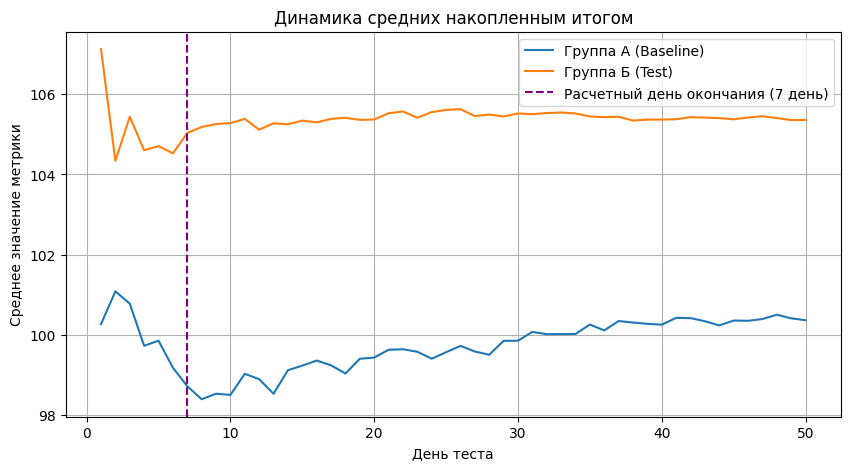

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(df_sim['day'], df_sim['mean_A'], label='Группа А (Baseline)')
plt.plot(df_sim['day'], df_sim['mean_B'], label='Группа Б (Test)')
plt.axvline(x=7, color='purple', linestyle='--', label='Расчетный день окончания (7 день)')
plt.xlabel('День теста')
plt.ylabel('Среднее значение метрики')
plt.title('Динамика средних накопленным итогом')
plt.legend()
plt.grid(True)
plt.show()

4. На основе `DataFrame` из предыдущего пункта постройте график динамики p-value по дням теста. Отложите вертикальную линию на этом же графике, показывающую кол-во дней, посчитанных в пункте 1. Сделайте эту линию пунктирной и измените цвет, который вам больше нравится. Также отложите горизонтальную линию – ваш уровень значимости $\alpha$.

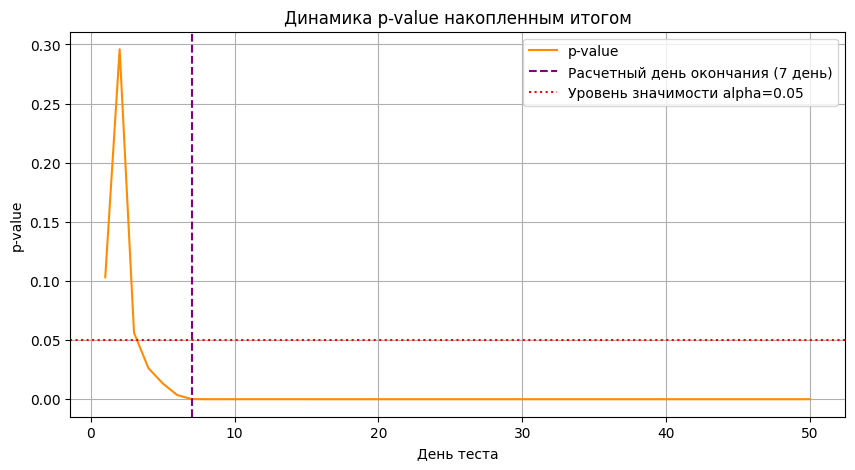

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(df_sim['day'], df_sim['p_value'], color='darkorange', label='p-value')
plt.axvline(x=7, color='purple', linestyle='--', label='Расчетный день окончания (7 день)')
plt.axhline(y=0.05, color='red', linestyle=':', label='Уровень значимости alpha=0.05')
plt.xlabel('День теста')
plt.ylabel('p-value')
plt.title('Динамика p-value накопленным итогом')
plt.legend()
plt.grid(True)
plt.show()

5. Перегенируруйте шаги 2-4 несколько раз, посмотрев на графики. Что вы видите? Что происходит с p-value в периодах:
    1. до кол-ва дней, посчитанных по формуле из п.1
    2. в точке кол-ва дней, посчитанных по формуле из п.1
    3. после кол-ва дней, посчитанных по формуле из п.1
    
    Опишите выводы максимально подробно.

Выводы:

На основе построенных графиков динамики средних и p-value накопленным итогом можно сделать следующие выводы:

1. Период до расчетного количества дней (дни 1–6).

 В первые дни теста значения средних сильно колеблются из-за малого объема данных (высокий шум и высокая дисперсия оценок). Как результат, график p-value ведет себя крайне нестабильно: на графике оно стартует выше 0.10, на 2-3 день резко подскакивает почти до 0.30, а затем устремляется вниз.

 Если бы мы подглядывали за тестом и проверяли результаты каждый день, то на 5-й или 6-й день мы бы увидели, что p-value упало ниже уровня alpha = 0.05. Приняв решение об остановке теста на этом этапе, аналитик совершил бы ошибку. На малых выборках такие просадки p-value часто обусловлены случайными отклонениями данных, а не стабильным эффектом.

 2. В точке расчетного количества дней (7-й день):

Именно к 7-му дню наши выборки накопили достаточный объем данных, чтобы сбалансировать дисперсию. На графике средних оценки стабилизируются: среднее группы А закрепляется в районе 100, а группы Б — в районе 105.

На 7-й день значение p-value уверенно зафиксировалось ниже критической отметки 0.05. Согласно дизайну эксперимента, именно в этой точке вероятность совершить ошибку первого рода строго зафиксирована на уровне alpha = 5%, а мощность теста составляет расчетные 1-beta=80%.

3. Период после расчетного количества дней (дни 8–50):

 После 7-го дня мы продолжаем накапливать данные, объем выборки растет, а стандартная ошибка среднего продолжает уменьшаться. Так как истинный эффект в данных действительно существует, то t-статистика непрерывно растет, а p-value стремится к нулю. Начиная с 10-12 дня оно падает до экстремально малых значений порядка 10^-6 - 10^-13.

6. Теперь предположим, что мы поменяли наш $MDE$ до $1$ у.е. То есть мат. ожидание в группе А осталось по-прежнему $100$, а вот в группе Б теперь $101$. Перегенерируйте пункты 2-4 для измененного $MDE$, при этом кол-во дней в п.1 не пересчитывайте. Что происходит с p-value? Сделайте выводы.

In [22]:
def simulate_ab_test_mde1(total_days=50):
    p_values = []
    mean_A = []
    mean_B = []

    data_A = np.random.normal(loc=100, scale=40, size=total_days * 100)
    data_B = np.random.normal(loc=101, scale=20, size=total_days * 100)

    for day in range(1, total_days + 1):
        current_A = data_A[:day * 100]
        current_B = data_B[:day * 100]
        mean_A.append(np.mean(current_A))
        mean_B.append(np.mean(current_B))
        _, p_val = sts.ttest_ind(current_A, current_B, equal_var=False)
        p_values.append(p_val)

    return pd.DataFrame({'day': range(1, total_days + 1),
                         'mean_A': mean_A,
                         'mean_B': mean_B,
                         'p_value': p_values})

df_mde1 = simulate_ab_test_mde1(50)


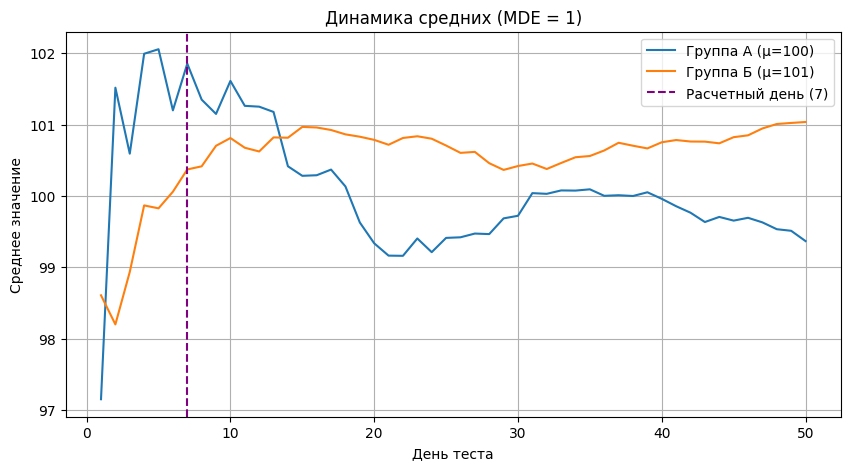

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(df_mde1['day'], df_mde1['mean_A'], label='Группа А (μ=100)')
plt.plot(df_mde1['day'], df_mde1['mean_B'], label='Группа Б (μ=101)')
plt.axvline(x=7, color='purple', linestyle='--', label='Расчетный день (7)')
plt.xlabel('День теста')
plt.ylabel('Среднее значение')
plt.title('Динамика средних (MDE = 1)')
plt.legend()
plt.grid(True)
plt.show()

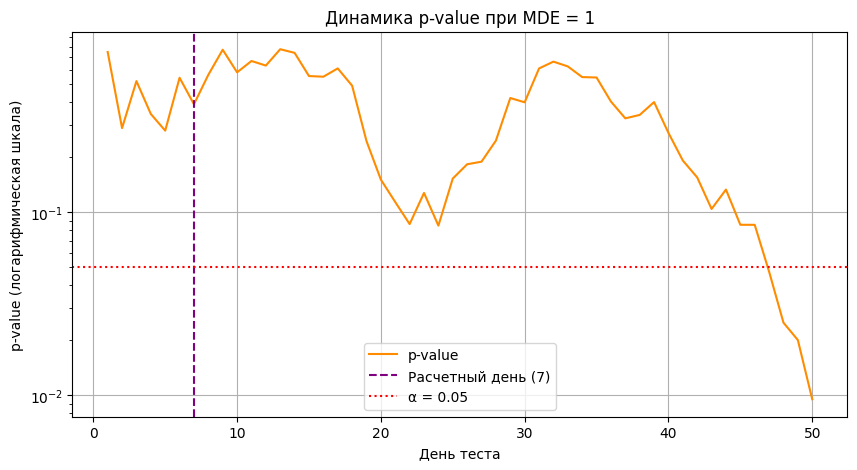

In [24]:
plt.figure(figsize=(10, 5))
plt.plot(df_mde1['day'], df_mde1['p_value'], color='darkorange', label='p-value')
plt.axvline(x=7, color='purple', linestyle='--', label='Расчетный день (7)')
plt.axhline(y=0.05, color='red', linestyle=':', label='α = 0.05')
plt.yscale('log')
plt.xlabel('День теста')
plt.ylabel('p-value (логарифмическая шкала)')
plt.title('Динамика p-value при MDE = 1')
plt.legend()
plt.grid(True)
plt.show()

Выводы:
Когда мы снижаем истинный эффект с 5 у.е. до 1 у.е., но при этом искусственно оставляем длительность теста равной 7 дням, поведение графиков меняется:

1. Поведение p-value на расчетный день (7-й день)

На 7-й день расчетная пунктирная линия пересекает график p-value в районе 0.40 - 0.50.

Это значительно выше нашего уровня значимости alpha = 0.05. Значит на 7-й день мы не можем отвергнуть нулевую гипотезу. Нам не хватает статистической мощности, чтобы заметить такой мелкий эффект. Тест завершается неудачей, несмотря на то, что в реальности изменения работают и среднее группы Б действительно на 1 у.е. выше.2.

Динамика средних значений:

Из-за того, что истинное различие между группами минимально, а стандартные отклонения выборок велики (sigma_A=40, sigma_B=20), случайный шум полностью заглушает эффект на ранних этапах. На графике средних видно, что в первые 15 дней синяя линия (Группа А) из-за случайности скачет даже выше оранжевой линии (Группа Б). Истинное положение дел — когда оранжевая линия стабильно закрепляется над синей с разрывом примерно в 1 единицу — начинает прослеживаться только после 25–30 дня теста.

Динамика p-value на длинной дистанции (дни 8–50):

Из-за малого эффекта график p-value долго находится в зоне высокой неопределенности (от 0.20 до 0.60).Только ближе к 45–50 дню накопленный объем данных становится достаточным, чтобы критерий начинал стабильно различать эту мелкую разницу, и p-value пересекает красную линию alpha = 0.05 сверху вниз.


Общий вывод: Нам не хватит мощности обнаружить такое мелкое различие за 7 дней.

__в) [20 баллов] Симуляция А/А-теста__

Теперь представим, что изменений на самом деле никаких нету, то есть мат. ожидание в обоих группах $100$, а $MDE = 0$

1. И снова перегенерируйте вышесделанные пункты 2-4. Что происходит с p-value? Может ли оно оказаться ниже уровня значимости?

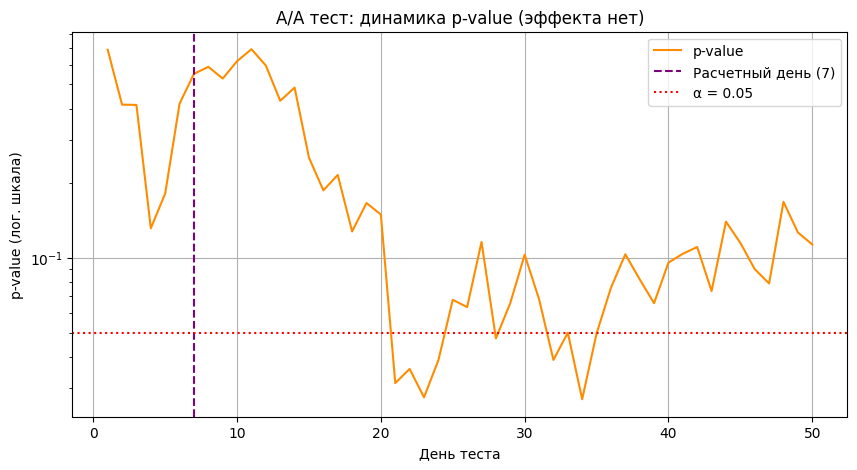

In [25]:
def simulate_aa_test(total_days=50, mu=100, sigma=40, daily_n=100):
    p_values = []
    mean_A = []
    mean_B = []

    data_A = np.random.normal(mu, sigma, total_days * daily_n)
    data_B = np.random.normal(mu, sigma, total_days * daily_n)

    for day in range(1, total_days + 1):
        current_A = data_A[:day * daily_n]
        current_B = data_B[:day * daily_n]
        mean_A.append(np.mean(current_A))
        mean_B.append(np.mean(current_B))
        _, p_val = sts.ttest_ind(current_A, current_B, equal_var=True)
        p_values.append(p_val)

    return pd.DataFrame({'day': range(1, total_days + 1),
                         'mean_A': mean_A,
                         'mean_B': mean_B,
                         'p_value': p_values})


df_aa = simulate_aa_test(50)

plt.figure(figsize=(10,5))
plt.plot(df_aa['day'], df_aa['p_value'], color='darkorange', label='p-value')
plt.axvline(x=7, color='purple', linestyle='--', label='Расчетный день (7)')
plt.axhline(y=0.05, color='red', linestyle=':', label='α = 0.05')
plt.yscale('log')
plt.xlabel('День теста')
plt.ylabel('p-value (лог. шкала)')
plt.title('A/A тест: динамика p-value (эффекта нет)')
plt.legend()
plt.grid(True)
plt.show()

Вывод:
p-value колеблется случайным образом в пределах от 0 до 1.

В любой момент времени (включая 7-й день и далее) p-value может оказаться ниже 0.05 – это ложноположительное срабатывание (ошибка первого рода).

Вероятность того, что p-value опустится ниже 0.05 в конкретный день, составляет ровно 5%.

В долгосрочной перспективе примерно 5% дней будут показывать значимый результат, хотя на самом деле эффекта нет.



2. Ну и напоследок, напишите функцию, которая генерирует p-value на последний день A/A теста. А затем запустите эту функцию $1000$ раз, собрав $1000$ значений p-value. Постройте гистограмму их распределения. Что вы видите?

__Подсказка:__ Для такой функции достаточно создать выборку один раз, изменив ее размер.

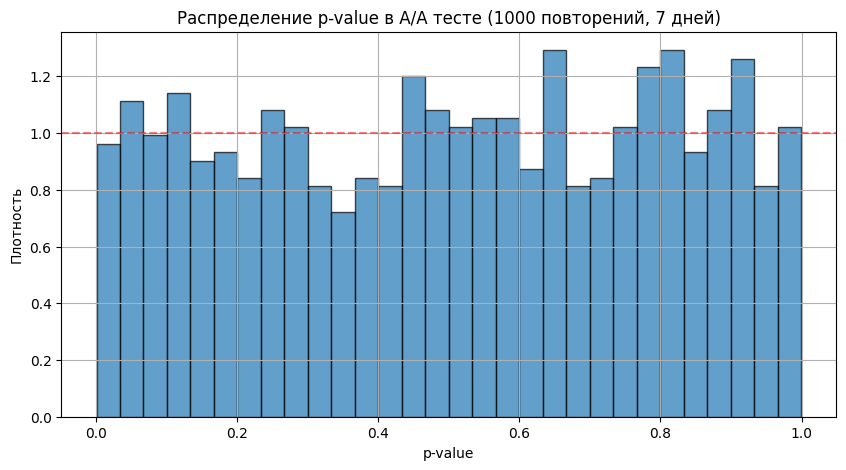

Доля ложноположительных результатов (p < 0.05): 0.052


In [26]:
def aa_pvalue_last_day(total_days=7, daily_n=100, mu=100, sigma=40):
    data_A = np.random.normal(mu, sigma, total_days * daily_n)
    data_B = np.random.normal(mu, sigma, total_days * daily_n)
    _, p_val = sts.ttest_ind(data_A, data_B, equal_var=True)
    return p_val

np.random.seed(42)
p_values_aa = [aa_pvalue_last_day(total_days=7) for _ in range(1000)]

plt.figure(figsize=(10,5))
plt.hist(p_values_aa, bins=30, density=True, edgecolor='black', alpha=0.7)
plt.xlabel('p-value')
plt.ylabel('Плотность')
plt.title('Распределение p-value в A/A тесте (1000 повторений, 7 дней)')
plt.axhline(y=1, color='red', linestyle='--', alpha=0.5)
plt.grid(True)
plt.show()

false_pos_rate = np.mean(np.array(p_values_aa) < 0.05)
print(f'Доля ложноположительных результатов (p < 0.05): {false_pos_rate:.3f}')

На графике видно:

Гистограмма демонстрирует равномерное распределение на отрезке [0; 1]. Плотность вероятности для всех бинов колеблется около отметки 1.0 (красная пунктирная линия).

